In [ ]:
"""
# Mini Project Idea

## Goal
My goal is to compare word frequencies in U.S. presidential speeches from different time periods to see how the language used by presidents has changed over time.

## Data Source
I plan to use publicly available presidential speeches, such as inaugural addresses, from online historical archives or government sources

## Comparisons
I will compare the most frequently used words in speeches from an older president and a more recent president. I will look for words that are used often by one president but less frequently by the other. I may also compare words related to topics such as the nation, government, war, freedom, the economy, and the American people.
"""

In [ ]:
"""
Comparing the first ever annual address made by George Washington in 1790 to the last annual address made by Donal Trump in 2026
"""

In [10]:
# Read both speeches
with open("Washington1790.txt", "r") as file:
    washington = file.read()
with open("Trump2026.txt", "r") as file:
    trump = file.read()
    

In [58]:
# Python's re is used to clean the speechs and converts them into a list of individual words
import re

def clean_and_split(text):
    # Make all words lowercase of analysis
    text = text.lower()

    # Replace common contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'s", "", text)

    # Extract words only
    words = re.findall(r'\b[a-z]+\b', text)

    return words
# Creates and splits both speechs
washington_words = clean_and_split(washington_clean)
trump_words = clean_and_split(trump_clean)


In [60]:
# Length of each speech
print ("Washington's total word count: ", len(washington_words))
print ("Trump's total word count: ", len(trump_words))


Washington's total word count:  1091
Trump's total word count:  10565


In [54]:
# Word frequency being comparing
# Focusing on the economy, national security, government, foreign affairs
comparison_words = [
    "america",
    "american",
    "country",
    "government",
    "people",
    "public",
    "congress",
    "economy",
    "security",
    "peace",
    "war",
    "freedom",
    "law",
    "jobs",
    "military",
    "illegal"
]

# Calculate frequency each president used the predetermined words
from collections import Counter

washington_counts = Counter(washington_words)
trump_counts = Counter(trump_words)

washington_total = len(washington_words)
trump_total = len(trump_words)

# Calculate how often each word appears per 1000 words
for word in comparison_words:
    washington_freq = (washington_counts[word] / washington_total) * 1000
    trump_freq = (trump_counts[word] / trump_total) * 1000

    print(
        word,
        "- Washington:", round(washington_freq, 2),
        "| Trump:", round(trump_freq, 2)
    )

america - Washington: 0.0 | Trump: 2.46
american - Washington: 0.0 | Trump: 3.03
country - Washington: 3.67 | Trump: 3.41
government - Washington: 3.67 | Trump: 0.47
people - Washington: 2.75 | Trump: 4.16
public - Washington: 4.58 | Trump: 0.09
congress - Washington: 0.0 | Trump: 1.23
economy - Washington: 0.92 | Trump: 0.28
security - Washington: 0.92 | Trump: 1.14
peace - Washington: 1.83 | Trump: 0.28
war - Washington: 0.92 | Trump: 1.23
freedom - Washington: 0.0 | Trump: 0.38
law - Washington: 0.92 | Trump: 0.57
jobs - Washington: 0.0 | Trump: 0.47
military - Washington: 0.92 | Trump: 1.8
illegal - Washington: 0.0 | Trump: 0.95


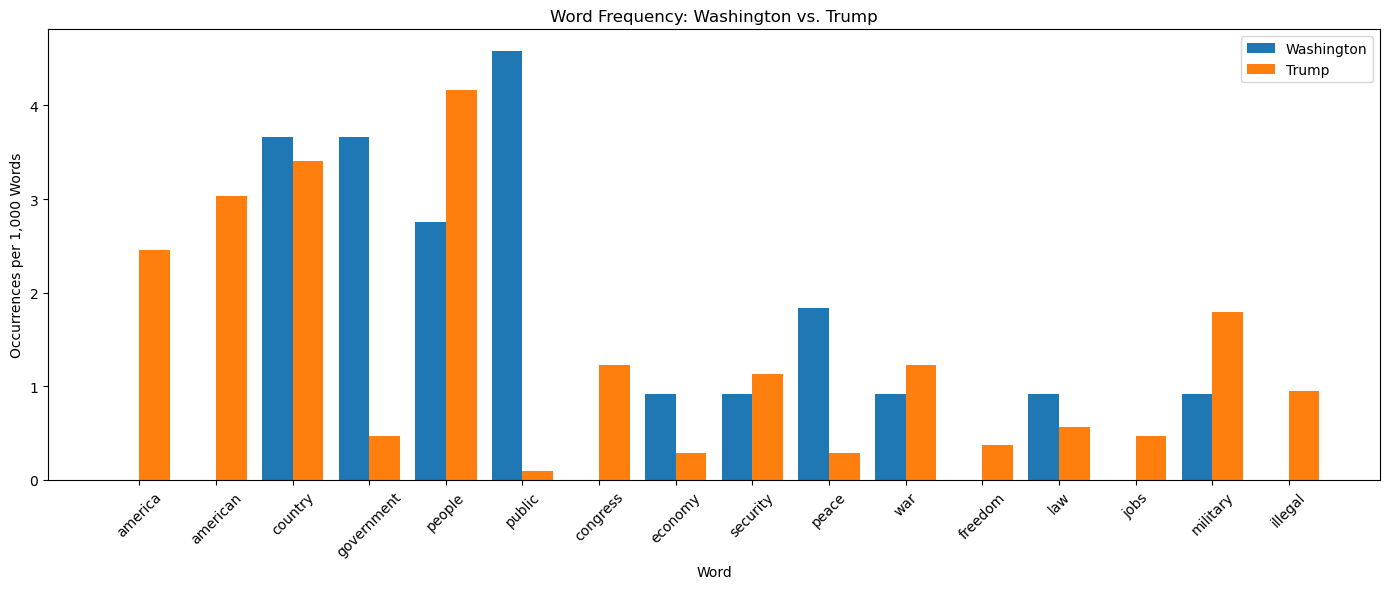

In [55]:
# Create a plot to better represent the frequency each president used the predetermined words
import matplotlib.pyplot as plt
import numpy as np

washington_freqs = []
trump_freqs = []

# calculate appears per 1000 words
for word in comparison_words:
    washington_freqs.append(
        (washington_counts[word] / washington_total) * 1000
    )
    
    trump_freqs.append(
        (trump_counts[word] / trump_total) * 1000
    )

# create graph
x = np.arange(len(comparison_words))
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(x - width/2, washington_freqs, width, label="Washington")
plt.bar(x + width/2, trump_freqs, width, label="Trump")

plt.xlabel("Word")
plt.ylabel("Occurrences per 1,000 Words")
plt.title("Word Frequency: Washington vs. Trump")

plt.xticks(x, comparison_words, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
"""
Method of Analysis
 - For this analysis, I compared George Washington's 1790 First Annual Address with Donald Trump's 
 2026 State of the Union Address. Because the speeches are very different in length
 - I first compared the total word count of each speech and then calculated how often each selected word appeared per
 1,000 words. I selected 16 words relation to government, the economy, national identity, and national security.
 - Doing analysis this way allows comparison across both speeches with the dominance of filler words such as to, the, it, and, etc.
"""

In [61]:
# Display a formatted table of the normalized word frequencies
# This makes the exact values from the graph easier to compare
print(f"{'Word':<12} {'Washington':>12} {'Trump':>12}")
print("-" * 38)

for word, w_freq, t_freq in zip(
    comparison_words,
    washington_freqs,
    trump_freqs
):
    print(f"{word:<12} {w_freq:>12.2f} {t_freq:>12.2f}")

Word           Washington        Trump
--------------------------------------
america              0.00         2.46
american             0.00         3.03
country              3.67         3.41
government           3.67         0.47
people               2.75         4.16
public               4.58         0.09
congress             0.00         1.23
economy              0.92         0.28
security             0.92         1.14
peace                1.83         0.28
war                  0.92         1.23
freedom              0.00         0.38
law                  0.92         0.57
jobs                 0.00         0.47
military             0.92         1.80
illegal              0.00         0.95


In [ ]:
"""
Results
The comparison showed several noticeable difference in word usage between the two speeches
    Washington used words such as "public," "government," and "peace" more frequently per 1,000 words, 
    while Trump used words such as "American," "America," "people," and "military" more frequently. 
    The word "illegal" appeared in Trump's speech but did not appear in Washington's speech.
    
Some words were used at similar rates despite the 236 year gap in speeches.
    For example, "country" appeared 3.67 times per 1,000 words in Washington's address and 3.41 times per
    1,000 words in Trump's address. Overall, the selected vocabulary shows differences in the topics and language
    emphasized in the two presidential addresses.
"""

In [62]:
# Compare the total number of times each selected word
# appears in Washington's and Trump's speeches

print(f"{'Word':<12} {'Washington':>12} {'Trump':>12}")
print("-" * 38)

for word in comparison_words:
    washington_count = washington_counts[word]
    trump_count = trump_counts[word]

    print(
        f"{word:<12} {washington_count:>12} {trump_count:>12}"
    )

Word           Washington        Trump
--------------------------------------
america                 0           26
american                0           32
country                 4           36
government              4            5
people                  3           44
public                  5            1
congress                0           13
economy                 1            3
security                1           12
peace                   2            3
war                     1           13
freedom                 0            4
law                     1            6
jobs                    0            5
military                1           19
illegal                 0           10
